In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import json
from pathlib import Path
from scipy.optimize import curve_fit
import statsmodels.api as sm

# Repo root: when run from figures_notebooks/, go up one level
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'figures_notebooks' else Path.cwd()

In [2]:
def _load_ml_data_from_ml_data_folder(n, noise_type, gamma, stat_type, ml_alpha_pattern, prep_error=None):
    """
    Load ML accuracy from ml_data via scenario1_train_results.json.
    prep_error: if given, match run where channel_config.strength == prep_error (epsilon_p).
    Otherwise match by gamma (backward compatible).
    """
    k_target = np.array([0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1])
    channel_type = 'thermal' if noise_type == 'relaxation' else noise_type
    q_suffix = 'q_11_12' if n >= 11 else 'q_5_10'
    if ml_alpha_pattern == 'all_ones':
        exp_name = f"exp_s1_fixed_alpha_all_ones_fixed_y_all_zeros_{q_suffix}"
    else:
        exp_name = f"exp_s1_fixed_alpha_half_ones_leading_fixed_y_all_zeros_{q_suffix}"
    results_file = REPO_ROOT / "ml_data" / exp_name / "scenario1_train_results.json"
    if not results_file.exists():
        raise FileNotFoundError(f"Not found: {results_file}")
    with open(results_file) as f:
        data = json.load(f)
    for run in data['runs']:
        meta = run['meta']
        if meta['n'] != n:
            continue
        cc = meta['channel_config']
        if cc['type'] != channel_type:
            continue
        if prep_error is not None:
            if abs(cc['strength'] - prep_error) > 1e-6:
                continue
        else:
            if cc['strength'] != gamma:
                continue
        k_list, y_list, q1_list, q3_list = [], [], [], []
        for per in run['per_nps']:
            nps = per['nps']
            k_list.append(np.log2(nps) / n)
            accs = [r['logreg']['val']['acc'] for r in per['independent_runs']['per_run']]
            med = float(np.median(accs))
            q1, q3 = np.percentile(accs, [25, 75])
            y_list.append(med)
            q1_list.append(q1)
            q3_list.append(q3)
        k_arr = np.array(k_list)
        mean_data = np.interp(k_target, k_arr, np.array(y_list))
        lower_data = np.interp(k_target, k_arr, np.array(q1_list))
        higher_data = np.interp(k_target, k_arr, np.array(q3_list))
        yerr = [lower_data, higher_data]
        return mean_data, yerr
    raise FileNotFoundError(f"No run for n={n}, {noise_type}, prep={prep_error} in {results_file}")

def get_data_to_plot_alphas_2(n, noise_type, gamma, method_type='hypergraph', stat_type='iqr', ml_alpha_pattern='all_ones', prep_error=None):
    """
    Load data for given (n, noise_type, gamma).
    For method_type='ml': loads from ml_data folder (all_ones or half_ones_leading exp).
    For hypergraph/shadow_surrogates: loads from paper_data_2.
    """
    if method_type == 'ml':
        try:
            return _load_ml_data_from_ml_data_folder(n, noise_type, gamma, stat_type, ml_alpha_pattern, prep_error=prep_error)
        except FileNotFoundError as e:
            if ml_alpha_pattern == 'half_ones':
                return get_data_to_plot_alphas_2(n, noise_type, gamma, method_type, stat_type, ml_alpha_pattern='all_ones', prep_error=prep_error)
            raise e

    general_dir = REPO_ROOT / "paper_data_2" / method_type
    fold = general_dir / f"{n}/{stat_type}"
    suffix = str(prep_error) if prep_error is not None else str(gamma)
    if stat_type == 'stats':
        mean_file = fold / f"alphas_means_{noise_type}_{suffix}.npy"
        lower_file = fold / f"alphas_stds_lower_{noise_type}_{suffix}.npy"
        higher_file = fold / f"alphas_stds_higher_{noise_type}_{suffix}.npy"
    elif stat_type == 'iqr':
        mean_file = fold / f"alphas_medians_{noise_type}_{suffix}.npy"
        lower_file = fold / f"alphas_iqrs_1_{noise_type}_{suffix}.npy"
        higher_file = fold / f"alphas_iqrs_3_{noise_type}_{suffix}.npy"
    else:
        raise ValueError("stat_type must be either 'stats' or 'iqr'")

    if not mean_file.exists():
        raise FileNotFoundError(f"No file found at {mean_file}")
    if not lower_file.exists():
        raise FileNotFoundError(f"No file found at {lower_file}")
    if not higher_file.exists():
        raise FileNotFoundError(f"No file found at {higher_file}")

    mean_data = np.load(mean_file)
    lower_data = np.load(lower_file)
    higher_data = np.load(higher_file)
    yerr = [lower_data, higher_data]
    return mean_data, yerr

In [3]:
def _fit_meta_scaling(noise_type, gamma, stat_type, method_type, regress_type, ml_alpha_pattern='all_ones', prep_error=None):
    """
    Extracts empirical slopes/intercepts across all available n,
    and returns the linear scaling polynomials for m(n) and x0(n).
    """
    k_target = np.array([0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1])
    n_qubits = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15]
    valid_n, slopes, intercepts = [], [], []

    for n_q in n_qubits:
        try:
            y_vals, yerr = get_data_to_plot_alphas_2(n_q, noise_type, gamma, method_type, stat_type, ml_alpha_pattern, prep_error=prep_error)
            eps = 1e-4
            y_clipped_all = np.clip(y_vals, 0.5 + eps, 1.0 - eps)
            visibility_all = 2.0 * y_clipped_all - 1.0
            v_logit2_all = np.log2(visibility_all / (1.0 - visibility_all))
            y_err_avg = (yerr[0] + yerr[1]) / 2.0
            v_err_all = 2.0 * y_err_avg
            v_err_clipped = np.clip(v_err_all, 1e-5, None)
            weights_all = (np.log(2)**2 * visibility_all**2 * (1.0 - visibility_all)**2) / (v_err_clipped**2)

            breakout_indices = np.where(y_vals > 0.55)[0]
            start_idx = max(0, breakout_indices[0] - 1) if len(breakout_indices) > 0 else 0
            plateau_indices = np.where(y_vals >= 0.99)[0]
            end_idx = plateau_indices[0] if len(plateau_indices) > 0 else len(y_vals) - 1
            if start_idx >= end_idx:
                start_idx, end_idx = 0, len(y_vals) - 1
            valid_idx = np.arange(start_idx, end_idx + 1)
            if len(valid_idx) < 2:
                continue

            k_valid = k_target[valid_idx]
            v_logit2_valid = v_logit2_all[valid_idx]
            weights_valid = weights_all[valid_idx]
            X = sm.add_constant(k_valid)
            if regress_type.lower() == 'wls':
                model = sm.WLS(v_logit2_valid, X, weights=weights_valid)
            elif regress_type.lower() == 'ols':
                model = sm.OLS(v_logit2_valid, X)
            else:
                raise ValueError("regress_type must be 'wls' or 'ols'")
            results = model.fit()
            intercepts.append(results.params[0])
            slopes.append(results.params[1])
            valid_n.append(n_q)
        except FileNotFoundError:
            continue

    m_poly = np.polyfit(valid_n, slopes, 1)
    int_poly = np.polyfit(valid_n, intercepts, 1)
    return m_poly, int_poly

def k_hat(target_accuracy, n_array, noise_type, gamma, stat_type='iqr', method_type='hypergraph', regress_type='wls', ml_alpha_pattern='all_ones', prep_error=None):
    """Vectorized: Predicts the required k value for a target accuracy across an array of n values."""
    n_array = np.asarray(n_array)
    m_poly, int_poly = _fit_meta_scaling(noise_type, gamma, stat_type, method_type, regress_type, ml_alpha_pattern, prep_error=prep_error)
    m_n = np.polyval(m_poly, n_array)
    x0_n = np.polyval(int_poly, n_array)
    eps = 1e-4
    A_clipped = np.clip(target_accuracy, 0.5 + eps, 1.0 - eps)
    visibility = 2.0 * A_clipped - 1.0
    target_logit2 = np.log2(visibility / (1.0 - visibility))
    k_predicted = (target_logit2 - x0_n) / m_n
    return k_predicted

def nps_hat(target_accuracy, n_array, noise_type, gamma, stat_type='iqr', method_type='hypergraph', regress_type='wls', ml_alpha_pattern='all_ones', prep_error=None):
    """Vectorized: Predicts the raw number of samples (n_ps) required across an array of n values."""
    n_array = np.asarray(n_array)
    k_predicted = k_hat(target_accuracy, n_array, noise_type, gamma, stat_type, method_type, regress_type, ml_alpha_pattern, prep_error=prep_error)
    nps_predicted = 2**(k_predicted * n_array)
    return nps_predicted

In [21]:
def quantum_decay_model(n, a, b):
    return 0.5 + a * np.exp(-b * n)

def plot_alpha_influence_two_panels(gamma=0.1, eta=0.05,
                                    regress_type='wls', stat_type='iqr'):
    """
    Two columns: devices B, C (B=T, C=S). Rows = dephasing, depolarizing, relaxation.
    Readout: 0.1% for B; 1% for C. Legends on C. Relaxation channel label at top of bottom row.
    """
    plt.style.use(str(REPO_ROOT / 'figures_notebooks' / 'single_column.mplstyle'))
    try:
        with open(REPO_ROOT / 'data' / 'vdevice_curves_full.json', 'r') as f:
            q_data = json.load(f)
    except FileNotFoundError:
        print("Could not find data/vdevice_curves_full.json. Please check the path.")
        return

    n_array_raw = np.array(q_data['nq_values'])

    devices = ['A/B', 'C']
    device_to_data = {'B': 'T', 'C': 'S'}  # display name -> data key
    readout_by_device = {'B': '0.1%', 'C': '1%'}
    nq_max_per_col = [75, 45]
    # B: omit n_q = 10 from the axis range
    xlim_xticks = [(5, 75, [10, 20, 30, 40, 50, 60, 70]), (5, 45, [10, 20, 30,40])]
    channels = ['dephasing', 'depolarizing', 'relaxation']
    alpha_keys = ['nq', 'nq/2']
    ml_alpha_by_key = {'nq': 'all_ones', 'nq/2': 'half_ones'}
    prep_vals = [0.01, 0.1]
    # Muted modern red/yellow/green palette shared across Figure 1-4 apps.
    alpha_color_by_prep = {0.01: {'nq': '#E8B4B4', 'nq/2': '#B9D8C0'}, 0.1: {'nq': '#D97777', 'nq/2': '#7FB38A'}}
    methods = [('hypergraph', '-', 'Hypergraph'), ('shadow_surrogates', '--', 'Eigenshadow'), ('ml', ':', 'ML')]
    extend_to_n = 120
    full_n_array = np.arange(n_array_raw.min(), extend_to_n + 1)

    yticks_rows_01 = [1e5, 1e10, 1e15, 1e20]  # within (1e2, 1e22)
    yticks_row2 = [1e5, 1e10, 1e20, 1e30]
    ylim_per_row = [(1e2, 1e22), (1e2, 1e22), (1e2, 1e38)]  # dephasing, depolarizing, relaxation
    h_refs = [(9e10, '1 d'), (3e13, '1 y'), (3e16, '1000 y')]

    legend_methods = [mlines.Line2D([0], [0], color='k', ls=ls, lw=1.5, label=name) for _, ls, name in methods]
    legend_alpha = [mlines.Line2D([0], [0], color='#D97777', ls='-', lw=1.5, label=r"$|\alpha|$ = $n_q$"),
                   mlines.Line2D([0], [0], color='#7FB38A', ls='-', lw=1.5, label=r"$|\alpha|$ = $n_q/2$")]
    legend_eps = [mlines.Line2D([0], [0], color='#b0b0b0', ls='-', lw=2.5, label=r"$\varepsilon_p$ = 0.01"),
                  mlines.Line2D([0], [0], color='#404040', ls='-', lw=2.5, label=r"$\varepsilon_p$ = 0.1")]

    fig, axes = plt.subplots(3, 2, figsize=(4, 6.5), sharex='col', sharey='row', gridspec_kw={'hspace': 0, 'wspace': 0})

    def get_quantum_full(acc_raw, n_raw, extend_n):
        if extend_n <= n_raw.max():
            return acc_raw
        extended_n = np.arange(n_raw.max() + 1, extend_n + 1)
        valid_idx = acc_raw > 0.501
        if np.sum(valid_idx) >= 3:
            popt, _ = curve_fit(quantum_decay_model, n_raw[valid_idx], acc_raw[valid_idx], p0=[0.5, 0.1])
            acc_ext = quantum_decay_model(extended_n, *popt)
        else:
            acc_ext = np.ones_like(extended_n) * 0.5
        return np.concatenate((acc_raw, acc_ext))

    debug_baseline_nps = 1.0

    for i_row, channel in enumerate(channels):
        for i_col, device in enumerate(devices):
            ax = axes[i_row, i_col]
            nq_max = nq_max_per_col[i_col]
            data_key = device_to_data[device]
            readout_error = readout_by_device[device]

            for prep in prep_vals:
                prep_key = str(prep)
                for alpha_key in alpha_keys:
                    ml_alpha = ml_alpha_by_key[alpha_key]
                    color = alpha_color_by_prep[prep][alpha_key]
                    try:
                        acc_raw = np.array(q_data['curves'][data_key][channel][alpha_key][readout_error][prep_key])
                    except KeyError as e:
                        print(f"Data missing: {e}")
                        continue

                    acc_full = get_quantum_full(acc_raw, n_array_raw, extend_to_n)
                    n_quantum = n_array_raw if len(acc_full) == len(n_array_raw) else np.concatenate([n_array_raw, np.arange(n_array_raw.max() + 1, extend_to_n + 1)])[:len(acc_full)]
                    acc_on_full = np.interp(full_n_array, n_quantum, acc_full)
                    target = acc_on_full - eta

                    for m_id, m_style, _ in methods:
                        ml_pattern = ml_alpha if m_id == 'ml' else 'all_ones'
                        nps_vals = nps_hat(target, full_n_array, channel, gamma, stat_type, m_id, regress_type, ml_alpha_pattern=ml_pattern, prep_error=prep)
                        nps_vals[target <= 0.5] = debug_baseline_nps
                        ax.plot(full_n_array, nps_vals, color=color, ls=m_style, lw=1.5, zorder=1)

            ax.set_yscale('log')
            x_min, x_max, xticks_list = xlim_xticks[i_col]
            ax.set_xlim(x_min, x_max)
            ax.set_xticks(xticks_list)
            y_min, y_max = ylim_per_row[i_row]
            ax.set_ylim(y_min, y_max)
            ax.set_yticks(yticks_rows_01 if i_row < 2 else yticks_row2)
            ax.grid(True, alpha=0.3)

            for y_val, label in h_refs:
                ax.axhline(y=y_val, color='black', linestyle=':', linewidth=0.8, alpha=0.6, zorder=0)
            if i_col == 1:
                for y_val, label in h_refs:
                    ax.text(nq_max, y_val, ' ' + label, transform=ax.transData, fontsize=7, alpha=0.8, va='center', ha='left')

            if i_row == 0:
                ax.set_title(device)
            if i_col == 1:
                ax2 = ax.twinx()
                ax2.set_yticks([])
                if i_row == 2:
                    ax2.text(1.02, 0.98, channel.capitalize(), transform=ax.transAxes, rotation=-90, va='top', ha='left', fontsize=8)
                else:
                    ax2.text(1.02, 0.02, channel.capitalize(), transform=ax.transAxes, rotation=-90, va='bottom', ha='left', fontsize=8)
            if i_row == 2:
                ax.set_xlabel("Number of qubits $n_q$")
            if i_col == 0:
                ax.set_ylabel("Required copies $n_c$")

            if i_row == 2 and i_col == 1:
                leg_m = ax.legend(handles=legend_methods, title="M-F method", loc="upper right", fontsize=8)
                ax.add_artist(leg_m)
            if i_row == 1 and i_col == 1:
                leg_a = ax.legend(handles=legend_alpha, loc="upper right", fontsize=8)
                ax.add_artist(leg_a)
            if i_row == 0 and i_col == 1:
                leg_eps = ax.legend(handles=legend_eps, loc="upper right", fontsize=8)
                ax.add_artist(leg_eps)

    plt.tight_layout()
    plt.savefig(str(REPO_ROOT / "figures_manuscript" / "fig4_dephasing_relax.pdf"), bbox_inches='tight')
    plt.show()


Bad key axes.grid.alpha in file /Users/krzywdaja/Documents/noisy-learning-advantage/figures_notebooks/single_column.mplstyle, line 30 ('axes.grid.alpha   : 0.35')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.4/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


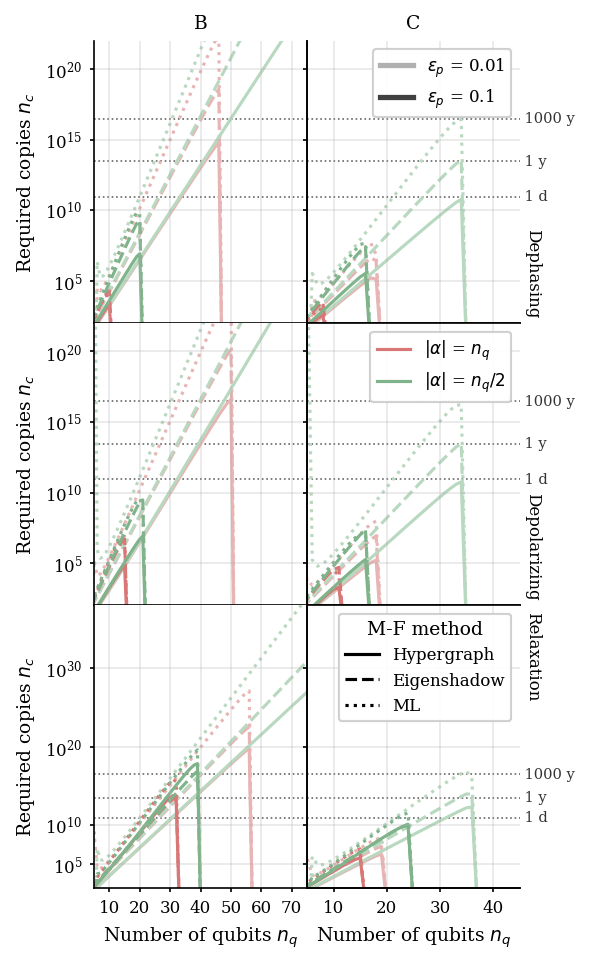

In [5]:
plot_alpha_influence_two_panels(gamma=0.1, eta=0.05)


Bad key axes.grid.alpha in file /Users/krzywdaja/Documents/noisy-learning-advantage/figures_notebooks/single_column.mplstyle, line 30 ('axes.grid.alpha   : 0.35')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.4/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


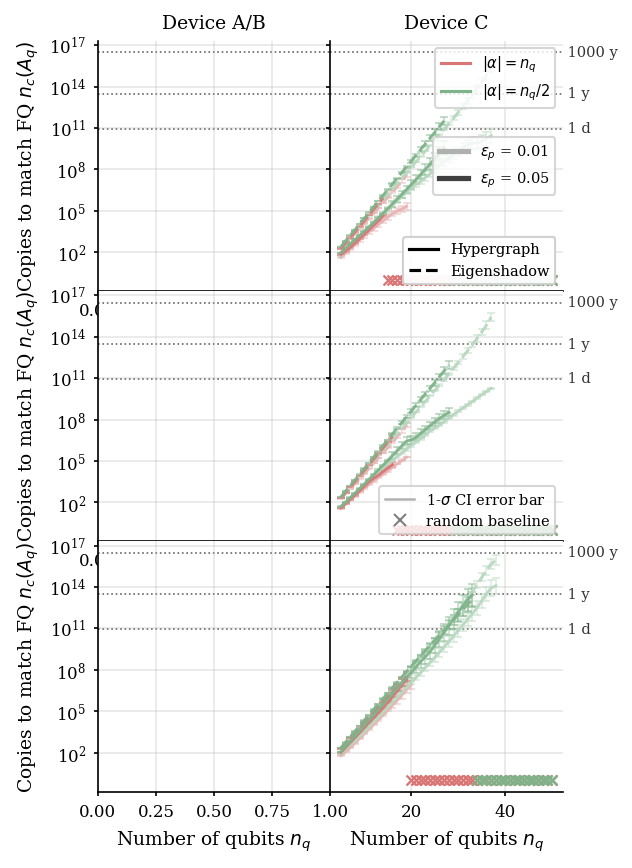

Saved: /Users/krzywdaja/Documents/noisy-learning-advantage/figures_manuscript/fig4_nps_nq_alpha_ch_from_curve_fitting_eps001_005.pdf
Saved: /Users/krzywdaja/Documents/noisy-learning-advantage/figures_manuscript/fig4_nps_nq_alpha_ch_from_curve_fitting_eps001_005.png


In [22]:
# New Fig.4-style plot from curve_fitting unified CSVs (with CI error bars)
import csv


def _read_unified_rows(csv_path, alpha_mode):
    rows = []
    with open(csv_path, "r", encoding="utf-8", newline="") as f:
        for r in csv.DictReader(f):
            rr = dict(r)
            rr["alpha_mode"] = alpha_mode
            rows.append(rr)
    return rows


def plot_fig4_from_curve_fitting_with_errorbars(
    eta_filter=0.01,
    epsilons=(0.01, 0.05),
    save_name="fig4_nps_nq_alpha_ch_from_curve_fitting_eps001_005",
):
    """
    Build the Fig.4 grid using curve_fitting unified CSV outputs.
    Uses error bars from nps_lo/nps_hi and filters to epsilon_p in epsilons.
    """

    # Following curve_fitting/generate_plots.txt structure.
    csv_sources = {
        "nq": [
            REPO_ROOT / "curve_fitting" / "plots_newQ_alpha_nq" / "ci68_IT" / "qvc_unified_eta_0p01_0p02_0p05_floor0p52_nhg1600_nml1600.csv",
            REPO_ROOT / "curve_fitting" / "plots_newQ_alpha_nq" / "ci68_S" / "qvc_unified_eta_0p01_0p02_0p05_floor0p52_nhg1600_nml1600.csv",
        ],
        "nq2": [
            REPO_ROOT / "curve_fitting" / "plots_newQ_alpha_nq2" / "ci68_IT" / "qvc_unified_eta_0p01_0p02_0p05_floor0p52_nhg1600_nml1600.csv",
            REPO_ROOT / "curve_fitting" / "plots_newQ_alpha_nq2" / "ci68_S" / "qvc_unified_eta_0p01_0p02_0p05_floor0p52_nhg1600_nml1600.csv",
        ],
    }

    rows = []
    for alpha_mode, paths in csv_sources.items():
        for p in paths:
            if not p.exists():
                raise FileNotFoundError(f"Missing CSV: {p}")
            rows.extend(_read_unified_rows(p, alpha_mode))

    devices = ["A/B", "C"]
    channels = ["dephasing", "depolarizing", "relaxation"]
    methods = ["hypergraph", "eigenshadow"]
    method_style = {"hypergraph": "-", "eigenshadow": "--"}
    alpha_order = ["nq", "nq2"]
    alpha_label = {"nq": r"$|\alpha|=n_q$", "nq2": r"$|\alpha|=n_q/2$"}

    # Palette aligned with notebook's style; darker = larger epsilon_p.
    alpha_color_by_eps = {
        0.01: {"nq": "#E8B4B4", "nq2": "#B9D8C0"},
        0.05: {"nq": "#D97777", "nq2": "#7FB38A"},
    }

    device_alias = {"I": "A", "T": "B", "S": "C", "A": "A", "B": "B", "C": "C"}
    readout_by_device = {"B": "0.1%", "C": "1%"}

    plt.style.use(str(REPO_ROOT / "figures_notebooks" / "single_column.mplstyle"))
    fig, axes = plt.subplots(3, 2, figsize=(4, 6.5), sharex=False, sharey=True, gridspec_kw={"hspace": 0, "wspace": 0})

    for i_row, channel in enumerate(channels):
        for i_col, device in enumerate(devices):
            ax = axes[i_row, i_col]

            for eps in epsilons:
                for alpha_mode in alpha_order:
                    color = alpha_color_by_eps[float(eps)][alpha_mode]
                    for method in methods:
                        xs, ys, ylos, yhis = [], [], [], []
                        xb, yb = [], []

                        for r in rows:
                            dev = device_alias.get(str(r.get("device", "")).strip(), str(r.get("device", "")).strip())
                            if dev != device:
                                continue
                            if str(r.get("channel", "")).strip().lower() != channel:
                                continue
                            if str(r.get("alpha_mode", "")).strip() != alpha_mode:
                                continue
                            if str(r.get("method", "")).strip() != method:
                                continue
                            if str(r.get("readout_error", "")).strip() != readout_by_device[device]:
                                continue

                            amp = float(r.get("amplitude", "nan"))
                            eta = float(r.get("eta", "nan"))
                            if not np.isfinite(amp) or not np.isfinite(eta):
                                continue
                            if abs(eta - float(eta_filter)) > 1e-12:
                                continue
                            if not any(abs(amp - float(ev)) <= 1e-12 for ev in epsilons):
                                continue
                            if abs(amp - float(eps)) > 1e-12:
                                continue

                            nq = float(r.get("nq", "nan"))
                            nps = float(r.get("nps", "nan"))
                            status = str(r.get("pred_status", "")).strip()
                            if not np.isfinite(nq) or not np.isfinite(nps) or nps <= 0:
                                continue

                            if status == "ok":
                                nps_lo = float(r.get("nps_lo", "nan"))
                                nps_hi = float(r.get("nps_hi", "nan"))
                                xs.append(nq)
                                ys.append(nps)
                                ylos.append(nps_lo)
                                yhis.append(nps_hi)
                            elif status == "random_baseline":
                                xb.append(nq)
                                yb.append(nps)

                        if xs:
                            order = np.argsort(xs)
                            x = np.asarray(xs)[order]
                            y = np.asarray(ys)[order]
                            lo = np.asarray(ylos)[order]
                            hi = np.asarray(yhis)[order]
                            valid_band = np.isfinite(lo) & np.isfinite(hi) & (lo > 0) & (hi > 0)

                            ax.plot(x, y, color=color, ls=method_style[method], lw=1.4, alpha=0.95, zorder=3)
                            if np.any(valid_band):
                                yerr = np.vstack([y[valid_band] - lo[valid_band], hi[valid_band] - y[valid_band]])
                                yerr = np.maximum(yerr, 0.0)
                                ax.errorbar(
                                    x[valid_band],
                                    y[valid_band],
                                    yerr=yerr,
                                    fmt="none",
                                    ecolor=color,
                                    elinewidth=0.8,
                                    alpha=0.45,
                                    capsize=1.8,
                                    zorder=2,
                                )

                        if xb:
                            order_b = np.argsort(xb)
                            xbr = np.asarray(xb)[order_b]
                            ybr = np.asarray(yb)[order_b]
                            ax.scatter(xbr, ybr, marker="x", color=color, s=22, linewidths=1.0, zorder=4, alpha=0.9)

            ax.set_yscale("log")
            ax.grid(True, alpha=0.3)
            if i_row == 2:
                ax.set_xlabel(r"Number of qubits $n_q$")
            if i_col == 0:
                ax.set_ylabel(r"Copies to match FQ $n_c(A_q)$")
            if i_row == 0:
                ax.set_title(f"Device {device}")

            # Match manuscript-style time reference lines.
            h_refs = [(9e10, "1 d"), (3e13, "1 y"), (3e16, "1000 y")]
            for y_val, label in h_refs:
                ax.axhline(y=y_val, color="black", linestyle=":", linewidth=0.8, alpha=0.6, zorder=0)
                if i_col == 1:
                    x_right = ax.get_xlim()[1]
                    ax.text(x_right, y_val, " " + label, fontsize=7, alpha=0.8, va="center", ha="left")

    legend_alpha = [
        mlines.Line2D([0], [0], color="#D97777", ls="-", lw=1.5, label=alpha_label["nq"]),
        mlines.Line2D([0], [0], color="#7FB38A", ls="-", lw=1.5, label=alpha_label["nq2"]),
    ]
    legend_eps = [
        mlines.Line2D([0], [0], color="#b0b0b0", ls="-", lw=2.5, label=r"$\varepsilon_p$ = 0.01"),
        mlines.Line2D([0], [0], color="#404040", ls="-", lw=2.5, label=r"$\varepsilon_p$ = 0.05"),
    ]
    legend_methods = [
        mlines.Line2D([0], [0], color="k", ls="-", lw=1.5, label="Hypergraph"),
        mlines.Line2D([0], [0], color="k", ls="--", lw=1.5, label="Eigenshadow"),
    ]
    legend_ci = [
        mlines.Line2D([0], [0], color="gray", lw=1.2, alpha=0.6, label=r"1-$\sigma$ CI error bar"),
        mlines.Line2D([0], [0], color="gray", marker="x", ls="", markersize=6, label="random baseline"),
    ]

    ax_leg = axes[0, 1]
    leg1 = ax_leg.legend(handles=legend_alpha, loc="upper right", fontsize=7)
    ax_leg.add_artist(leg1)
    leg2 = ax_leg.legend(handles=legend_eps, loc="center right", fontsize=7)
    ax_leg.add_artist(leg2)
    leg3 = ax_leg.legend(handles=legend_methods, loc="lower right", fontsize=7)
    ax_leg.add_artist(leg3)
    axes[1, 1].legend(handles=legend_ci, loc="lower right", fontsize=7)

    out_pdf = REPO_ROOT / "figures_manuscript" / f"{save_name}.pdf"
    out_png = REPO_ROOT / "figures_manuscript" / f"{save_name}.png"
    out_pdf.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(str(out_pdf), bbox_inches="tight")
    plt.savefig(str(out_png), dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {out_pdf}")
    print(f"Saved: {out_png}")


plot_fig4_from_curve_fitting_with_errorbars(eta_filter=0.01, epsilons=(0.01, 0.05))


Bad key axes.grid.alpha in file /Users/krzywdaja/Documents/noisy-learning-advantage/figures_notebooks/single_column.mplstyle, line 30 ('axes.grid.alpha   : 0.35')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.4/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


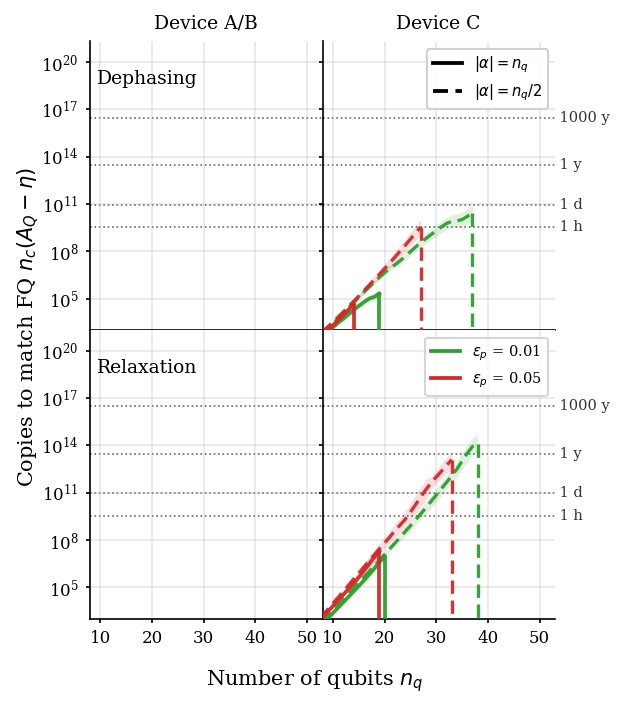

Saved: /Users/krzywdaja/Documents/noisy-learning-advantage/figures_manuscript/fig4_dephasing_relax.pdf.pdf
Saved: /Users/krzywdaja/Documents/noisy-learning-advantage/figures_manuscript/fig4_dephasing_relax.pdf.png


In [ ]:
# Variant: min(Hypergraph, Eigenshadow), line + shaded band only, no depolarizing row
import csv
from collections import defaultdict


def _read_unified_rows(csv_path, alpha_mode):
    rows = []
    with open(csv_path, "r", encoding="utf-8", newline="") as f:
        for r in csv.DictReader(f):
            rr = dict(r)
            rr["alpha_mode"] = alpha_mode
            rows.append(rr)
    return rows


def plot_fig4_min_method_lines_only(
    eta_filter=0.01,
    epsilons=(0.01, 0.05),
    save_name="fig4_dephasing_relax.pdf",
):
    csv_sources = {
        "nq": [
            REPO_ROOT / "curve_fitting" / "plots_newQ_alpha_nq" / "ci68_IT" / "qvc_unified_eta_0p01_0p02_0p05_floor0p52_nhg1600_nml1600.csv",
            REPO_ROOT / "curve_fitting" / "plots_newQ_alpha_nq" / "ci68_S" / "qvc_unified_eta_0p01_0p02_0p05_floor0p52_nhg1600_nml1600.csv",
        ],
        "nq2": [
            REPO_ROOT / "curve_fitting" / "plots_newQ_alpha_nq2" / "ci68_IT" / "qvc_unified_eta_0p01_0p02_0p05_floor0p52_nhg1600_nml1600.csv",
            REPO_ROOT / "curve_fitting" / "plots_newQ_alpha_nq2" / "ci68_S" / "qvc_unified_eta_0p01_0p02_0p05_floor0p52_nhg1600_nml1600.csv",
        ],
    }

    rows = []
    for alpha_mode, paths in csv_sources.items():
        for p in paths:
            if not p.exists():
                raise FileNotFoundError(f"Missing CSV: {p}")
            rows.extend(_read_unified_rows(p, alpha_mode))

    device_alias = {"I": "A", "T": "B", "S": "C", "A": "A", "B": "B", "C": "C"}
    readout_by_device = {"B": "0.1%", "C": "1%"}

    devices = ["B", "C"]
    channels = ["dephasing", "relaxation"]  # skip depolarizing
    alpha_order = ["nq", "nq2"]
    alpha_label = {"nq": r"$|\alpha|=n_q$", "nq2": r"$|\alpha|=n_q/2$"}
    methods = ["hypergraph", "eigenshadow"]

    # Reversed encoding: epsilon by colors, alpha by linestyle.
    color_by_eps = {0.01: "#2CA02C", 0.05: "#D62728", 0.1:"k"}  # green/red for epsilon_p
    ls_by_alpha = {"nq": "-", "nq2": (0, (4, 2))}   # solid/dashed for alpha

    grouped = defaultdict(list)
    for r in rows:
        dev = device_alias.get(str(r.get("device", "")).strip(), str(r.get("device", "")).strip())
        ch = str(r.get("channel", "")).strip().lower()
        alpha_mode = str(r.get("alpha_mode", "")).strip()
        method = str(r.get("method", "")).strip()
        status = str(r.get("pred_status", "")).strip()
        ro = str(r.get("readout_error", "")).strip()

        try:
            amp = float(r.get("amplitude", "nan"))
            eta = float(r.get("eta", "nan"))
            nq = float(r.get("nq", "nan"))
            nps = float(r.get("nps", "nan"))
            nps_lo = float(r.get("nps_lo", "nan"))
            nps_hi = float(r.get("nps_hi", "nan"))
        except Exception:
            continue

        if dev not in devices or ch not in channels or alpha_mode not in alpha_order:
            continue
        if method not in methods:
            continue
        if ro != readout_by_device[dev]:
            continue
        if abs(eta - float(eta_filter)) > 1e-12:
            continue
        if not any(abs(amp - float(ev)) <= 1e-12 for ev in epsilons):
            continue

        grouped[(dev, ch, alpha_mode, amp, method)].append({
            "nq": nq,
            "nps": nps,
            "nps_lo": nps_lo,
            "nps_hi": nps_hi,
            "status": status,
        })

    def _min_over_methods(dev, ch, alpha_mode, amp):
        ok_by_method = {}
        rb_by_method = {}
        for m in methods:
            rs = grouped.get((dev, ch, alpha_mode, amp, m), [])
            ok = {}
            rb = {}
            for rr in rs:
                nq = rr["nq"]
                nps = rr["nps"]
                if not np.isfinite(nq) or not np.isfinite(nps) or nps <= 0:
                    continue
                if rr["status"] == "ok":
                    ok[nq] = (nps, rr["nps_lo"], rr["nps_hi"])
                elif rr["status"] == "random_baseline":
                    rb[nq] = nps
            ok_by_method[m] = ok
            rb_by_method[m] = rb

        # pointwise minimum over methods for "ok"
        x_ok_all = sorted(set().union(*[set(ok_by_method[m].keys()) for m in methods]))
        x_ok, y_ok, lo_ok, hi_ok = [], [], [], []
        for x in x_ok_all:
            candidates = []
            for m in methods:
                if x in ok_by_method[m]:
                    y, lo, hi = ok_by_method[m][x]
                    if np.isfinite(y) and y > 0:
                        candidates.append((y, lo, hi))
            if not candidates:
                continue
            y, lo, hi = min(candidates, key=lambda t: t[0])
            x_ok.append(x)
            y_ok.append(y)
            lo_ok.append(lo)
            hi_ok.append(hi)

        # pointwise minimum over methods for random baseline
        x_rb_all = sorted(set().union(*[set(rb_by_method[m].keys()) for m in methods]))
        x_rb, y_rb = [], []
        for x in x_rb_all:
            vals = [rb_by_method[m][x] for m in methods if x in rb_by_method[m] and np.isfinite(rb_by_method[m][x]) and rb_by_method[m][x] > 0]
            if vals:
                x_rb.append(x)
                y_rb.append(min(vals))

        return np.array(x_ok), np.array(y_ok), np.array(lo_ok), np.array(hi_ok), np.array(x_rb), np.array(y_rb)

    plt.style.use(str(REPO_ROOT / "figures_notebooks" / "single_column.mplstyle"))
    fig, axes = plt.subplots(2, 2, figsize=(4, 5), sharex=False, sharey=True, gridspec_kw={"hspace": 0, "wspace": 0})

    for i_row, channel in enumerate(channels):
        for i_col, device in enumerate(devices):
            ax = axes[i_row, i_col]
            for eps in epsilons:
                eps = float(eps)
                for alpha_mode in alpha_order:
                    color = color_by_eps[eps]
                    ls = ls_by_alpha[alpha_mode]
                    x_ok, y_ok, lo_ok, hi_ok, x_rb, y_rb = _min_over_methods(device, channel, alpha_mode, eps)

                    if x_ok.size:
                        order = np.argsort(x_ok)
                        x_ok, y_ok = x_ok[order], y_ok[order]
                        lo_ok, hi_ok = lo_ok[order], hi_ok[order]
                        lw_main = 1.8 if alpha_mode == "nq" else 1.6
                        ax.plot(x_ok, y_ok, color=color, ls=ls, lw=lw_main, alpha=0.95, zorder=3)

                        valid = np.isfinite(lo_ok) & np.isfinite(hi_ok) & (lo_ok > 0) & (hi_ok > 0)
                        if np.any(valid):
                            ax.fill_between(x_ok[valid], lo_ok[valid], hi_ok[valid], color=color, alpha=0.14, linewidth=0, zorder=2)

                    # (2) connect rise to random-baseline and force terminal drop to n_c = 1
                    if x_rb.size:
                        order_rb = np.argsort(x_rb)
                        x_rb, y_rb = x_rb[order_rb], y_rb[order_rb]
                        if x_ok.size and x_rb[0] > x_ok[-1]:
                            ax.plot([x_ok[-1], x_rb[0]], [y_ok[-1], y_rb[0]], color=color, ls=ls, lw=lw_main, alpha=0.95, zorder=3)
                        ax.plot(x_rb, y_rb, color=color, ls=ls, lw=lw_main, alpha=0.95, zorder=3)
                        x_end = x_rb[-1]
                    elif x_ok.size:
                        x_end = x_ok[-1]
                    else:
                        x_end = None

                    if x_end is not None:
                        y_anchor = y_rb[-1] if x_rb.size else y_ok[-1]
                        if np.isfinite(y_anchor) and y_anchor > 1.0:
                            # vertical terminal segment down to random guess complexity.
                            ax.plot([x_end, x_end], [y_anchor, 1.0], color=color, ls=ls, lw=lw_main, alpha=0.95, zorder=3)

            ax.set_yscale("log")
            ax.set_ylim(1e3, 2e21)
            if i_col == 0:
                ax.set_xlim(8, 53)
                ax.set_xticks(np.arange(10, 51, 10))
            else:
                ax.set_xlim(8, 53)
                ax.set_xticks(np.arange(10, 51, 10))
            ax.grid(True, alpha=0.3)
            if i_row == 0:
                ax.tick_params(labelbottom=False)
                ax.set_title("Device A/B" if i_col == 0 else f"Device {device}")

            # Row labels in first column.
            if i_col == 0 and i_row == 0:
                ax.text(0.03, 0.9, "Dephasing", transform=ax.transAxes, ha="left", va="top", fontsize=9)
            if i_col == 0 and i_row == 1:
                ax.text(0.03, 0.9, "Relaxation", transform=ax.transAxes, ha="left", va="top", fontsize=9)

            h_refs = [(3600*1e6, "1 h"), (9e10, "1 d"), (3e13, "1 y"), (3e16, "1000 y")]
            for y_val, label in h_refs:
                ax.axhline(y=y_val, color="black", linestyle=":", linewidth=0.8, alpha=0.6, zorder=0)
                if i_col == 1:
                    x_right = ax.get_xlim()[1]
                    ax.text(x_right, y_val, " " + label, fontsize=7, alpha=0.8, va="center", ha="left")

    # (4) only alpha + epsilon legends
    legend_alpha = [
        mlines.Line2D([0], [0], color="black", ls=ls_by_alpha["nq"], lw=1.8, label=alpha_label["nq"]),
        mlines.Line2D([0], [0], color="black", ls=ls_by_alpha["nq2"], lw=1.8, label=alpha_label["nq2"]),
    ]
    legend_eps = [
        mlines.Line2D([0], [0], color=color_by_eps[0.01], ls="-", lw=1.8, label=r"$\varepsilon_p$ = 0.01"),
        mlines.Line2D([0], [0], color=color_by_eps[0.05], ls="-", lw=1.8, label=r"$\varepsilon_p$ = 0.05"),
    ]

    ax_leg = axes[0, 1]
    leg1 = ax_leg.legend(handles=legend_alpha, loc="upper right", fontsize=7)
    ax_leg.add_artist(leg1)

    # Put epsilon legend on second row, second column at top.
    ax_eps = axes[1, 1]
    ax_eps.legend(handles=legend_eps, loc="upper right", fontsize=7)

    # Single shared axis labels (centered on full figure).
    fig.supxlabel(r"Number of qubits $n_q$", fontsize=10)
    fig.supylabel(r"Copies to match FQ $n_c(A_Q-\eta)$", fontsize=10,x = -0.0)

    out_pdf = REPO_ROOT / "figures_manuscript" / f"{save_name}.pdf"
    out_png = REPO_ROOT / "figures_manuscript" / f"{save_name}.png"
    out_pdf.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(str(out_pdf), bbox_inches="tight")
    plt.savefig(str(out_png), dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {out_pdf}")
    print(f"Saved: {out_png}")


plot_fig4_min_method_lines_only(eta_filter=0.01, epsilons=(0.01, 0.05))